Importing the dependencies

In [1]:
!nvidia-smi

Thu Sep 17 01:21:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load and explore the data
data = pd.read_csv('./Reactor_Feasibility_Plot.csv')
print("Dataset Shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nDataset Info:")
print(data.info())
print("\nDescriptive Statistics:")
print(data.describe())

FileNotFoundError: [Errno 2] No such file or directory: './Reactor_Feasibility_Plot.csv'

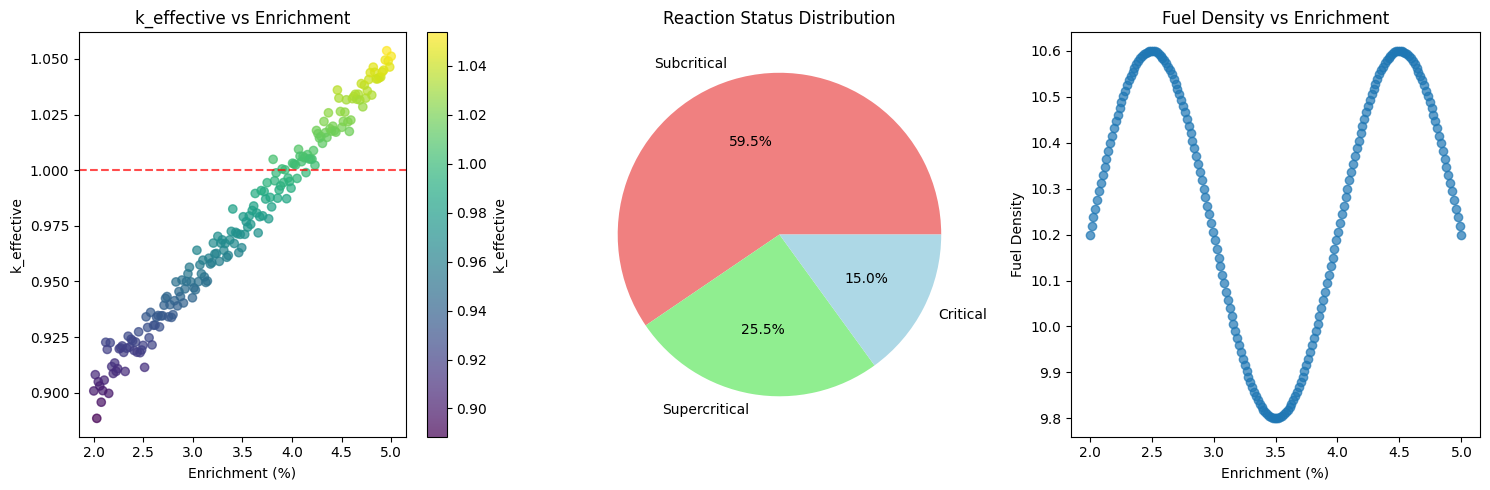


Correlation Matrix:
                    enrichment_percent  fuel_density  moderator_density  \
enrichment_percent        1.000000e+00  2.163666e-14       1.931309e-14   
fuel_density              2.163666e-14  1.000000e+00       7.943769e-01   
moderator_density         1.931309e-14  7.943769e-01       1.000000e+00   
k_eff                     9.923970e-01  4.734663e-03       8.063922e-03   

                       k_eff  
enrichment_percent  0.992397  
fuel_density        0.004735  
moderator_density   0.008064  
k_eff               1.000000  


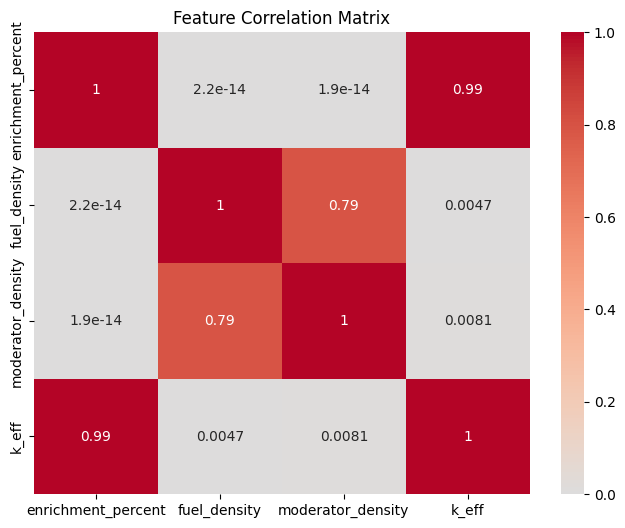

In [2]:
# Data Analysis and Visualization
plt.figure(figsize=(15, 5))

# Plot 1: k_eff vs enrichment
plt.subplot(1, 3, 1)
plt.scatter(data['enrichment_percent'], data['k_eff'], c=data['k_eff'], cmap='viridis', alpha=0.7)
plt.xlabel('Enrichment (%)')
plt.ylabel('k_effective')
plt.title('k_effective vs Enrichment')
plt.colorbar(label='k_effective')
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Critical (k=1)')

# Plot 2: Reaction status distribution
plt.subplot(1, 3, 2)
status_counts = data['reaction_status'].value_counts()
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'lightblue'])
plt.title('Reaction Status Distribution')

# Plot 3: Fuel density vs enrichment
plt.subplot(1, 3, 3)
plt.scatter(data['enrichment_percent'], data['fuel_density'], alpha=0.7)
plt.xlabel('Enrichment (%)')
plt.ylabel('Fuel Density')
plt.title('Fuel Density vs Enrichment')

plt.tight_layout()
plt.show()

# Correlation analysis
correlation_matrix = data[['enrichment_percent', 'fuel_density', 'moderator_density', 'k_eff']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [3]:
# Data Augmentation using Interpolation
def augment_data(original_data, num_interpolated_points=200):
    """Augment dataset by generating intermediate values using interpolation"""

    # Sort by enrichment for proper interpolation
    sorted_data = original_data.sort_values('enrichment_percent')

    # Create finer enrichment grid
    enrichment_fine = np.linspace(
        sorted_data['enrichment_percent'].min(),
        sorted_data['enrichment_percent'].max(),
        num_interpolated_points
    )

    # Interpolate other features
    fuel_density_fine = np.interp(enrichment_fine,
                                 sorted_data['enrichment_percent'],
                                 sorted_data['fuel_density'])

    moderator_density_fine = np.interp(enrichment_fine,
                                      sorted_data['enrichment_percent'],
                                      sorted_data['moderator_density'])

    k_eff_fine = np.interp(enrichment_fine,
                          sorted_data['enrichment_percent'],
                          sorted_data['k_eff'])

    # Create augmented dataframe
    augmented_data = pd.DataFrame({
        'enrichment_percent': enrichment_fine,
        'fuel_density': fuel_density_fine,
        'moderator_density': moderator_density_fine,
        'k_eff': k_eff_fine
    })

    # Add reaction status based on k_eff
    augmented_data['reaction_status'] = pd.cut(augmented_data['k_eff'],
                                             bins=[-np.inf, 0.95, 1.05, np.inf],
                                             labels=['Subcritical', 'Critical', 'Supercritical'])

    return augmented_data

# Generate augmented dataset
augmented_data = augment_data(data, num_interpolated_points=300)
print(f"Original data shape: {data.shape}")
print(f"Augmented data shape: {augmented_data.shape}")

# Combine original and augmented data
combined_data = pd.concat([data, augmented_data], ignore_index=True)
combined_data = combined_data.drop_duplicates(subset=['enrichment_percent']).sort_values('enrichment_percent')

print(f"Combined data shape: {combined_data.shape}")

Original data shape: (200, 5)
Augmented data shape: (300, 5)
Combined data shape: (498, 5)


Training set size: 398
Test set size: 100
Linear Regression:
  R² Score: 0.9899
  RMSE: 0.0048

Decision Tree:
  R² Score: 0.9938
  RMSE: 0.0037

Random Forest:
  R² Score: 0.9977
  RMSE: 0.0023

Polynomial Regression (deg=3):
  R² Score: 0.9898
  RMSE: 0.0048

Best model: Random Forest

Feature Importance:
              feature  importance
0  enrichment_percent    0.872865
2   moderator_density    0.111646
1        fuel_density    0.015489


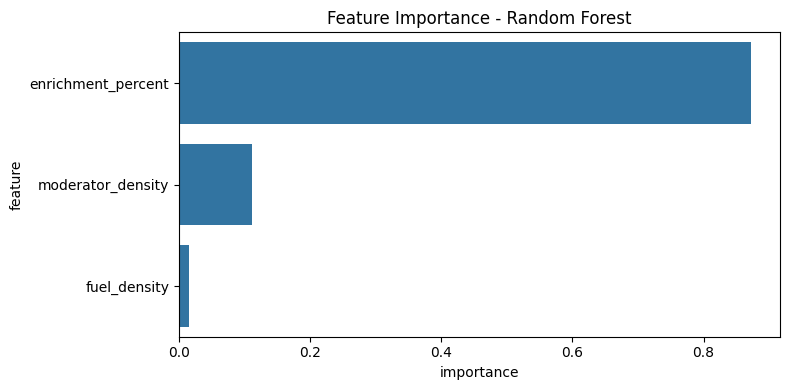

In [4]:
# Model Development - Regression

# Prepare features and target
X = combined_data[['enrichment_percent', 'fuel_density', 'moderator_density']]
y = combined_data['k_eff']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Polynomial Regression (deg=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('linear', LinearRegression())
    ])
}

# Train and evaluate models
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        'model': model,
        'r2': r2,
        'rmse': rmse,
        'predictions': y_pred
    }

    print(f"{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print()

# Select best model
best_model_name = max(results, key=lambda x: results[x]['r2'])
best_model = results[best_model_name]['model']
print(f"Best model: {best_model_name}")

# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title('Feature Importance - Random Forest')
    plt.tight_layout()
    plt.show()

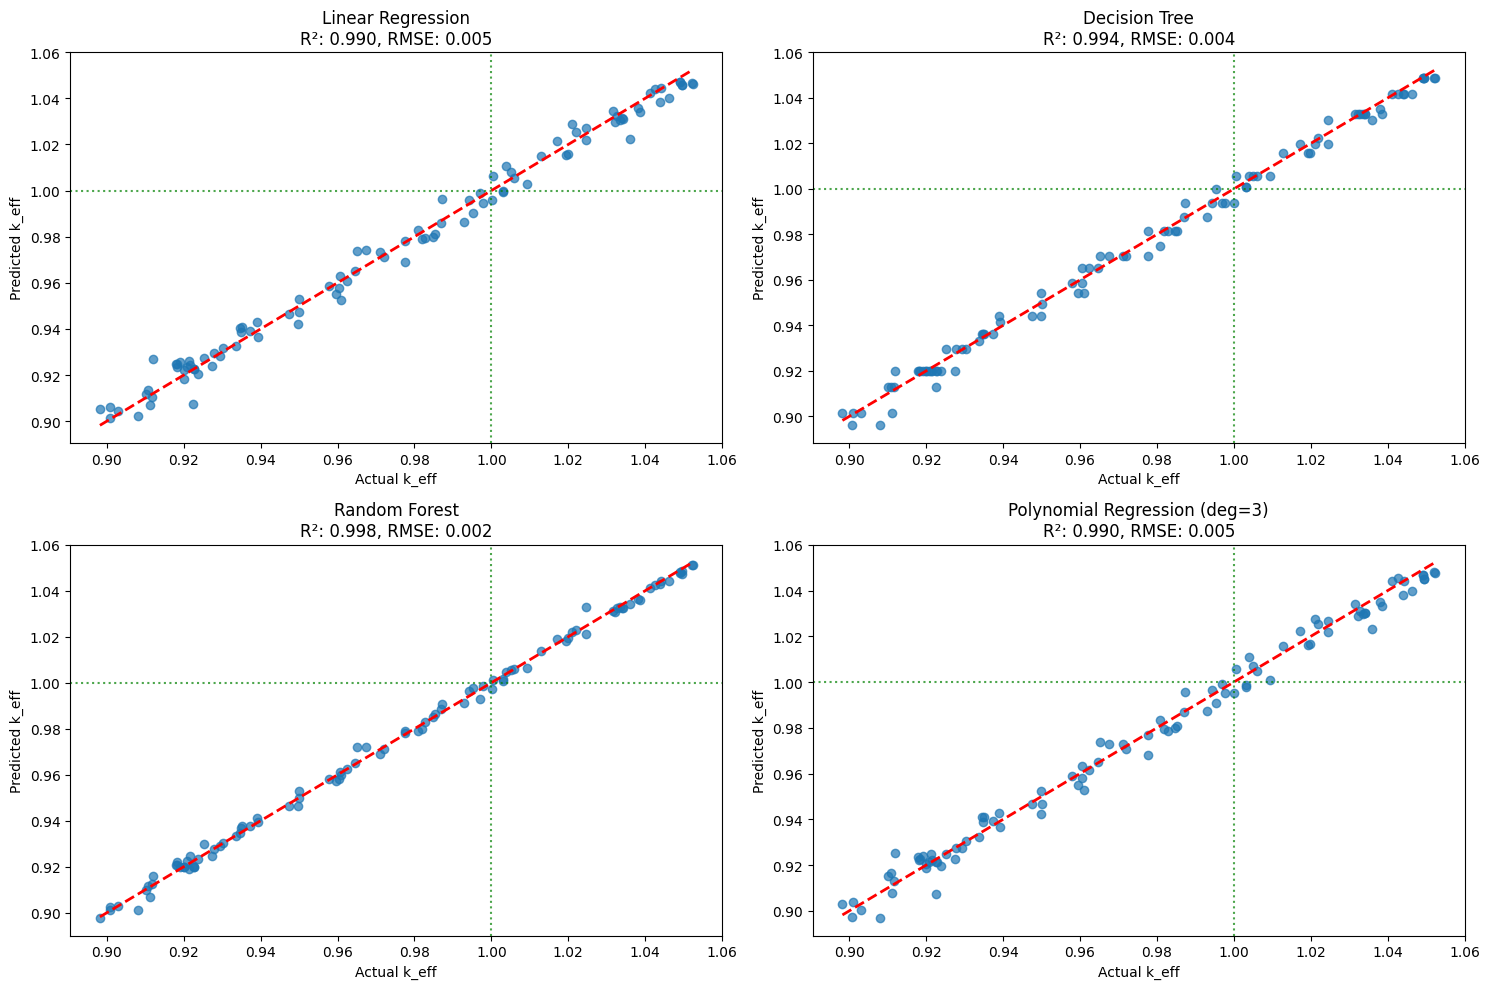

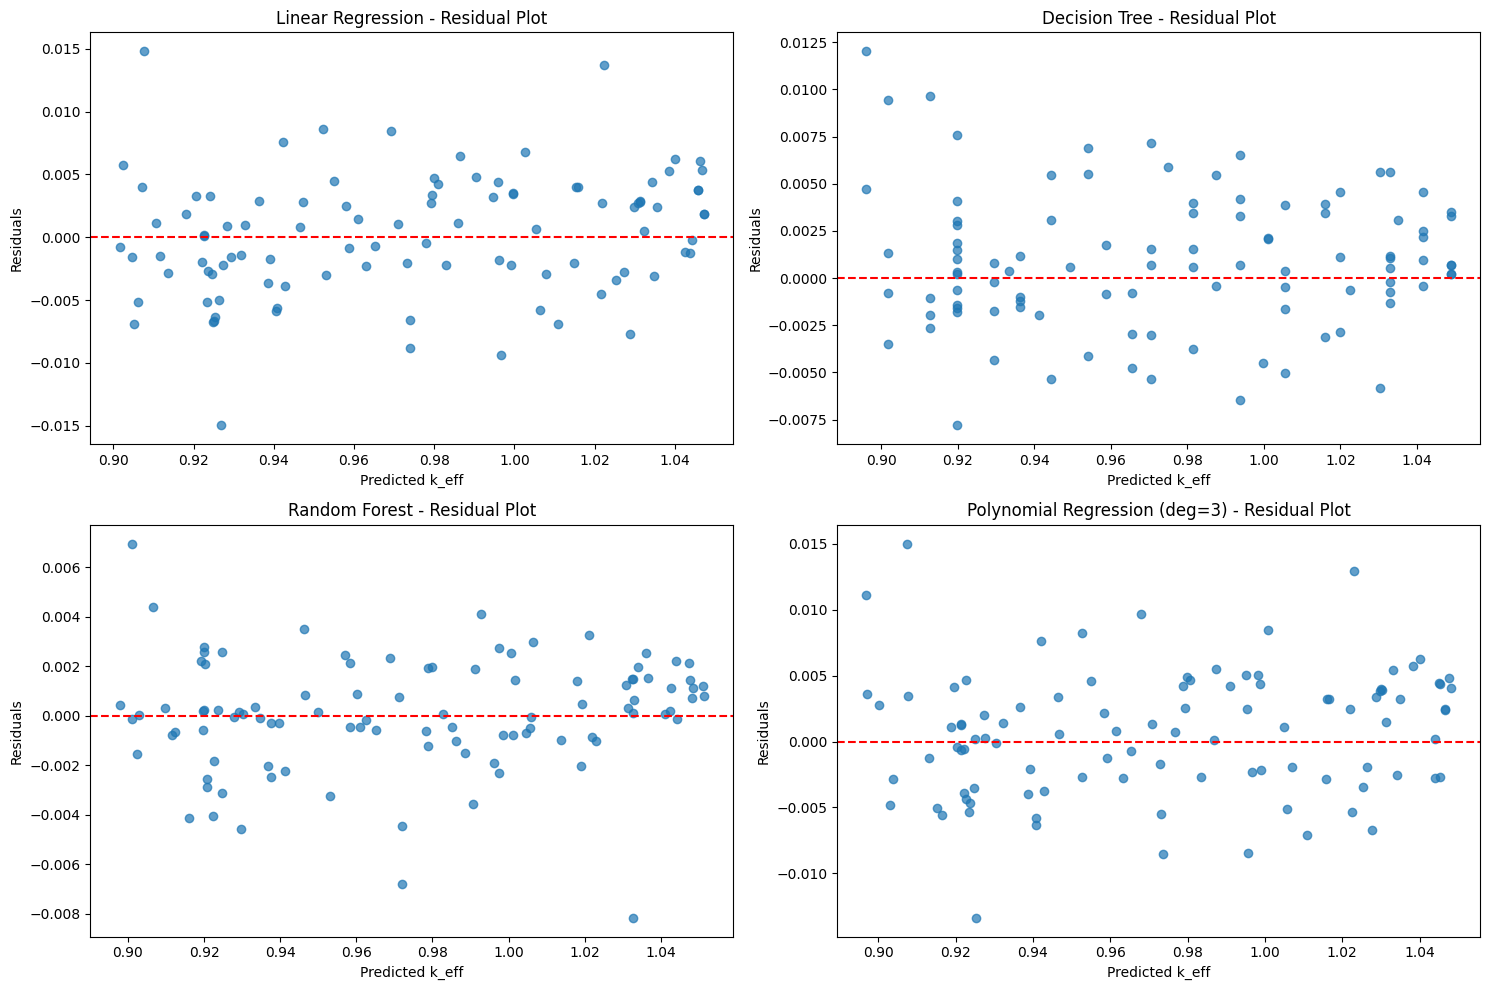

In [5]:
# Visualization - Regression Results

# Plot predicted vs actual for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['predictions']

    axes[idx].scatter(y_test, y_pred, alpha=0.7)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Actual k_eff')
    axes[idx].set_ylabel('Predicted k_eff')
    axes[idx].set_title(f'{name}\nR²: {result["r2"]:.3f}, RMSE: {result["rmse"]:.3f}')

    # Add perfect prediction line
    axes[idx].axhline(y=1.0, color='green', linestyle=':', alpha=0.7, label='Critical')
    axes[idx].axvline(x=1.0, color='green', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.legend()
plt.show()

# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['predictions']
    residuals = y_test - y_pred

    axes[idx].scatter(y_pred, residuals, alpha=0.7)
    axes[idx].axhline(y=0, color='red', linestyle='--')
    axes[idx].set_xlabel('Predicted k_eff')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{name} - Residual Plot')

plt.tight_layout() 
plt.legend()
plt.show()

Classification Results:
Accuracy: 0.9800

Classification Report:
               precision    recall  f1-score   support

     Critical       1.00      0.97      0.98        66
  Subcritical       0.97      1.00      0.99        33
Supercritical       0.50      1.00      0.67         1

     accuracy                           0.98       100
    macro avg       0.82      0.99      0.88       100
 weighted avg       0.99      0.98      0.98       100


Classification Feature Importance:
              feature  importance
0  enrichment_percent    0.895517
1        fuel_density    0.058388
2   moderator_density    0.046095


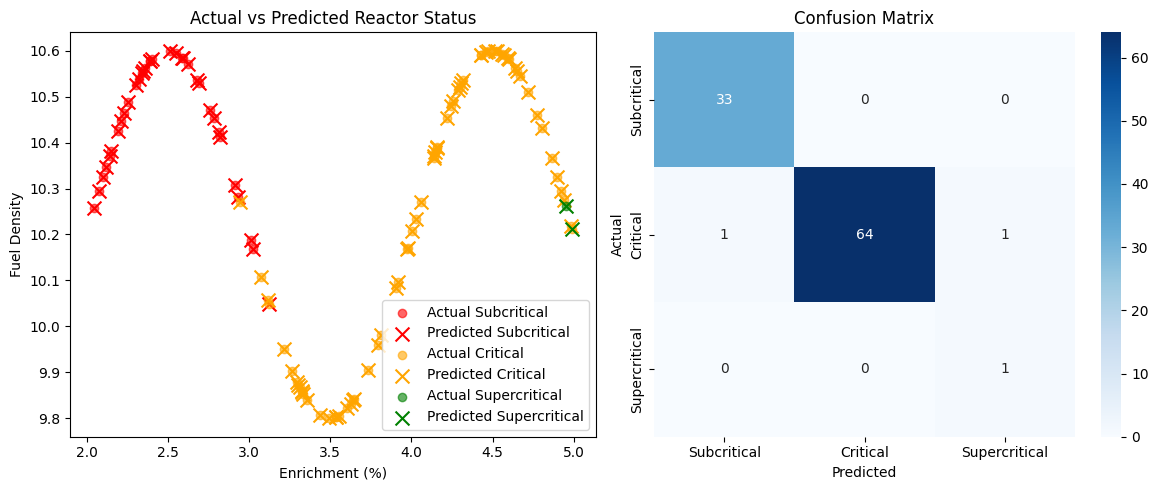

In [6]:
# Classification Model (Optional Extension)

# Create classification labels based on k_eff
def classify_reactor_status(k_eff):
    if k_eff < 0.95:
        return 'Subcritical'
    elif k_eff <= 1.05:
        return 'Critical'
    else:
        return 'Supercritical'

# Add classification target
combined_data['status_class'] = combined_data['k_eff'].apply(classify_reactor_status)

# Prepare classification data
X_clf = combined_data[['enrichment_percent', 'fuel_density', 'moderator_density']]
y_clf = combined_data['status_class']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Train classification model
clf_model = DecisionTreeClassifier(random_state=42, max_depth=4)
clf_model.fit(X_train_clf, y_train_clf)

# Evaluate classifier
y_pred_clf = clf_model.predict(X_test_clf)
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("Classification Results:")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

# Feature importance for classification
clf_feature_importance = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': clf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nClassification Feature Importance:")
print(clf_feature_importance)

# Plot classification boundaries (simplified 2D visualization)
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted classes
plt.subplot(1, 2, 1)
colors = {'Subcritical': 'red', 'Critical': 'orange', 'Supercritical': 'green'}
for status in colors.keys():
    mask_actual = y_test_clf == status
    mask_pred = y_pred_clf == status
    plt.scatter(X_test_clf[mask_actual]['enrichment_percent'],
                X_test_clf[mask_actual]['fuel_density'],
                c=colors[status], marker='o', alpha=0.6, label=f'Actual {status}')
    plt.scatter(X_test_clf[mask_pred]['enrichment_percent'],
                X_test_clf[mask_pred]['fuel_density'],
                c=colors[status], marker='x', s=100, label=f'Predicted {status}')

plt.xlabel('Enrichment (%)')
plt.ylabel('Fuel Density')
plt.title('Actual vs Predicted Reactor Status')
plt.legend()

# Plot 2: Confusion Matrix Visualization
plt.subplot(1, 2, 2)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=['Subcritical', 'Critical', 'Supercritical'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Subcritical', 'Critical', 'Supercritical'],
            yticklabels=['Subcritical', 'Critical', 'Supercritical'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

Example Predictions:
Enrichment: 2.5%
Predicted k_eff: 0.9188
Reactor Status: Subcritical
----------------------------------------
Enrichment: 3.0%
Predicted k_eff: 0.9452
Reactor Status: Subcritical
----------------------------------------
Enrichment: 3.5%
Predicted k_eff: 0.9764
Reactor Status: Critical
----------------------------------------
Enrichment: 4.0%
Predicted k_eff: 0.9932
Reactor Status: Critical
----------------------------------------
Enrichment: 4.5%
Predicted k_eff: 1.0211
Reactor Status: Critical
----------------------------------------


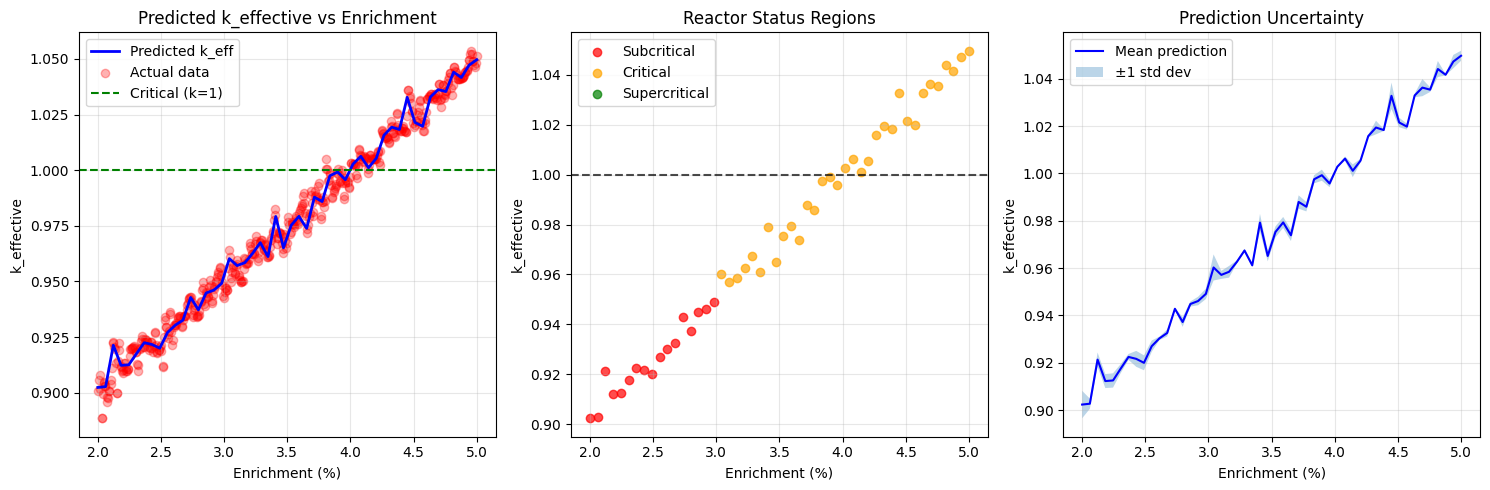


Best model saved as: reactor_k_eff_predictor.pkl

FINAL MODEL DEPLOYMENT
Best Model: Random Forest
Test R² Score: 0.9977
Test RMSE: 0.0023

Usage:
result = predict_reactor_behavior(enrichment_percent, fuel_density, moderator_density)
Returns: {predicted_k_eff, predicted_status, ...}


In [7]:
# Final Model Deployment and Prediction Function

def predict_reactor_behavior(enrichment_percent, fuel_density=None, moderator_density=None):
    """
    Predict k_effective and reactor status for given enrichment percentage
    """
    # If densities not provided, use typical values from data
    if fuel_density is None:
        # Find closest enrichment in data and use corresponding densities
        idx = (combined_data['enrichment_percent'] - enrichment_percent).abs().idxmin()
        fuel_density = combined_data.loc[idx, 'fuel_density']
        moderator_density = combined_data.loc[idx, 'moderator_density']

    # Prepare input features
    input_features = np.array([[enrichment_percent, fuel_density, moderator_density]])

    # Predict k_eff
    k_eff_pred = best_model.predict(input_features)[0]

    # Classify status
    status_pred = classify_reactor_status(k_eff_pred)

    return {
        'enrichment_percent': enrichment_percent,
        'fuel_density': fuel_density,
        'moderator_density': moderator_density,
        'predicted_k_eff': k_eff_pred,
        'predicted_status': status_pred
    }

# Test the prediction function with some examples
test_enrichments = [2.5, 3.0, 3.5, 4.0, 4.5]
print("Example Predictions:")
print("=" * 70)
for enrichment in test_enrichments:
    result = predict_reactor_behavior(enrichment)
    print(f"Enrichment: {enrichment}%")
    print(f"Predicted k_eff: {result['predicted_k_eff']:.4f}")
    print(f"Reactor Status: {result['predicted_status']}")
    print("-" * 40)

# Create prediction curve across enrichment range
enrichment_range = np.linspace(2.0, 5.0, 50)
predictions = [predict_reactor_behavior(env) for env in enrichment_range]

k_eff_predictions = [p['predicted_k_eff'] for p in predictions]
status_predictions = [p['predicted_status'] for p in predictions]

# Plot comprehensive prediction results
plt.figure(figsize=(15, 5))

# Plot 1: Predicted k_eff curve
plt.subplot(1, 3, 1)
plt.plot(enrichment_range, k_eff_predictions, 'b-', linewidth=2, label='Predicted k_eff')
plt.scatter(combined_data['enrichment_percent'], combined_data['k_eff'],
           alpha=0.3, color='red', label='Actual data')
plt.axhline(y=1.0, color='green', linestyle='--', label='Critical (k=1)')
plt.xlabel('Enrichment (%)')
plt.ylabel('k_effective')
plt.title('Predicted k_effective vs Enrichment')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Status regions
plt.subplot(1, 3, 2)
colors = {'Subcritical': 'red', 'Critical': 'orange', 'Supercritical': 'green'}
for status in colors.keys():
    mask = [s == status for s in status_predictions]
    plt.scatter(np.array(enrichment_range)[mask], np.array(k_eff_predictions)[mask],
               c=colors[status], label=status, alpha=0.7)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Enrichment (%)')
plt.ylabel('k_effective')
plt.title('Reactor Status Regions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Prediction uncertainty
plt.subplot(1, 3, 3)
if hasattr(best_model, 'predict'):
    # For ensemble methods, we can get some uncertainty estimate
    if hasattr(best_model, 'estimators_'):
        all_predictions = []
        for estimator in best_model.estimators_:
            preds = []
            for env in enrichment_range:
                idx = (combined_data['enrichment_percent'] - env).abs().idxmin()
                fuel_dens = combined_data.loc[idx, 'fuel_density']
                mod_dens = combined_data.loc[idx, 'moderator_density']
                input_vec = np.array([[env, fuel_dens, mod_dens]])
                preds.append(estimator.predict(input_vec)[0])
            all_predictions.append(preds)

        all_predictions = np.array(all_predictions)
        mean_pred = np.mean(all_predictions, axis=0)
        std_pred = np.std(all_predictions, axis=0)

        plt.plot(enrichment_range, mean_pred, 'b-', label='Mean prediction')
        plt.fill_between(enrichment_range, mean_pred - std_pred, mean_pred + std_pred,
                        alpha=0.3, label='±1 std dev')
        plt.xlabel('Enrichment (%)')
        plt.ylabel('k_effective')
        plt.title('Prediction Uncertainty')
        plt.legend()
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the best model for deployment
import joblib
model_filename = 'reactor_k_eff_predictor.pkl'
joblib.dump(best_model, model_filename)
print(f"\nBest model saved as: {model_filename}")

# Provide the prediction equation/function
print("\n" + "="*70)
print("FINAL MODEL DEPLOYMENT")
print("="*70)
print(f"Best Model: {best_model_name}")
print(f"Test R² Score: {results[best_model_name]['r2']:.4f}")
print(f"Test RMSE: {results[best_model_name]['rmse']:.4f}")
print("\nUsage:")
print("result = predict_reactor_behavior(enrichment_percent, fuel_density, moderator_density)")
print("Returns: {predicted_k_eff, predicted_status, ...}")